# ⛏️ PeakyMiner - Tarea 4: Análisis Exploratorio de Datos (EDA)
## Cuaderno 02: Exploración, Visualización y Hallazgos del Ecosistema GH-AW

**Proyecto:** PeakyMiner (`pkminer`)  
**Dataset:** GitHub Agentic Workflows (GH-AW)  
**Origen de Datos:** Tablas procesadas y limpias en `eda/data/processed/` (generadas en el Cuaderno 01)  
**Aislamiento:** Este cuaderno no comparte memoria con el Cuaderno 01; consume exclusivamente artefactos persistidos.  

---

### 🎯 Objetivos de este Cuaderno
1. **Carga y Unidades de Análisis:** Cargar las 3 tablas procesadas y definir rigurosamente las entidades de análisis (repositorio, workflow individual, trigger/evento).
2. **Distribución de Workflows por Repositorio:** Evaluar la concentración y asimetría de flujos de trabajo mediante estadística descriptiva, histogramas con KDE y boxplots.
3. **Exploración del Frontmatter:** Analizar la presencia de metadatos, los motores de IA (`model_engine`), desanidar herramientas declaradas (`tools`) y estudiar la distribución de eventos de activación (`event_type`).
4. **Exploración del Body (Prompts y Directivas):** Estudiar la longitud léxica de las instrucciones (`body_word_count`) e inspeccionar cualitativamente los workflows extremos.
5. **Relaciones entre Variables (Preguntas de Investigación):**
   * *Pregunta 1 (Multi-tabla):* Popularidad del repositorio (`stars_count`) vs. Complejidad del agente (`body_word_count` y número de `tools`).
   * *Pregunta 2 (Atributos cruzados):* Longitud de directivas según el motor de IA seleccionado (`model_engine`).
6. **Hallazgos Clave y Limitaciones:** Sintetizar conclusiones empíricas respaldadas por datos y reflexionar críticamente sobre las limitaciones metodológicas del estudio.


### 🛠️ Configuración del Entorno y Estilo Visual Uniforme
Configuración de Matplotlib y Seaborn con el tema estandarizado del proyecto (`whitegrid`, `palette="muted"`).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuración del estilo visual uniforme según especificación técnica
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# Ajustes en Pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.precision", 3)

print("✅ Entorno de visualización y análisis inicializado correctamente.")


✅ Entorno de visualización y análisis inicializado correctamente.


---
## 1. Carga de los Datos para el Análisis

### 1.1 Lectura Estricta desde `eda/data/processed/`
Garantizamos reproducibilidad e independencia de sesión leyendo directamente las tablas depuradas en el Cuaderno 01.


In [2]:
def locate_processed_dir() -> Path:
    """Localiza de forma robusta el directorio de datos procesados."""
    candidates = [
        Path("data/processed"),
        Path("eda/data/processed"),
        Path("../eda/data/processed"),
        Path("../../eda/data/processed"),
    ]
    for c in candidates:
        if c.exists() and (c / "workflows_clean.parquet").exists():
            return c.resolve()
    raise FileNotFoundError(
        "No se encontraron las tablas limpias en eda/data/processed/. "
        "Asegúrate de ejecutar primero el Cuaderno 01 (01_descripcion_y_calidad.ipynb)."
    )

processed_dir = locate_processed_dir()
print(f"📁 Directorio de datos procesados localizado: {processed_dir}")

# Carga de las 3 entidades depuradas
df_repos = pd.read_parquet(processed_dir / "repositories_clean.parquet")
df_workflows = pd.read_parquet(processed_dir / "workflows_clean.parquet")
df_triggers = pd.read_parquet(processed_dir / "workflow_triggers_clean.parquet")

print(f"✅ Repositorios cargados: {len(df_repos)}")
print(f"✅ Workflows cargados:    {len(df_workflows)}")
print(f"✅ Triggers cargados:     {len(df_triggers)}")


📁 Directorio de datos procesados localizado: /home/bfl/Code/PeakyMiner/eda/data/processed
✅ Repositorios cargados: 292
✅ Workflows cargados:    1368
✅ Triggers cargados:     3475


### 1.2 Declaración Formal de las Unidades de Análisis

El análisis empírico opera sobre tres unidades o niveles de agregación claramente diferenciados:

1. **Unidad de Nivel Repositorio (`repositories_clean`):**
   * *Entidad:* Repositorio de código público en GitHub.
   * *Preguntas que responde:* ¿Qué tipo de proyectos adoptan agentes? ¿Cómo se vincula la popularidad (estrellas/forks), el lenguaje principal y la licencia con la cantidad de agentes desplegados?
2. **Unidad de Nivel Flujo de Trabajo / Agente (`workflows_clean`):**
   * *Entidad:* Archivo de definición `.md` en `.github/workflows/`.
   * *Preguntas que responde:* ¿Qué modelos de lenguaje motorizan a los agentes? ¿Qué nivel de complejidad léxica tienen sus prompts? ¿Qué facultades y herramientas tienen autorizadas?
3. **Unidad de Nivel Evento / Disparador (`workflow_triggers_clean`):**
   * *Entidad:* Regla individual de activación de un flujo (`push`, `schedule`, `workflow_dispatch`, etc.).
   * *Preguntas que responde:* ¿Bajo qué modalidad operativa trabajan los agentes (reactiva a cambios de código, programada en cron o manual bajo demanda)?


---
## 2. Distribución de Archivos por Repositorio

### 2.1 Agrupación y Estadística Descriptiva
Agrupamos la tabla de workflows por `repo_id` para computar cuántos flujos de trabajo de agentes alberga cada repositorio.


In [3]:
# Conteo de workflows por repositorio
wf_per_repo = df_workflows.groupby("repo_id").size().rename("workflow_count")

# Incorporación de metadatos del repositorio para análisis enriquecido
repo_density = df_repos.merge(wf_per_repo, on="repo_id", how="left")
repo_density["workflow_count"] = repo_density["workflow_count"].fillna(0).astype(int)

# Cálculo de estadísticas descriptivas completas
counts_series = repo_density["workflow_count"]

stats_summary = pd.DataFrame({
    "Métrica": [
        "Total Repositorios Evaluados",
        "Mínimo de Workflows",
        "Primer Cuartil (Q1 - 25%)",
        "Mediana (Q2 - 50%)",
        "Media Aritmética",
        "Tercer Cuartil (Q3 - 75%)",
        "Máximo de Workflows",
        "Desviación Estándar (Std)",
        "Rango Intercuartílico (IQR)",
        "Coeficiente de Asimetría (Skewness)"
    ],
    "Valor": [
        len(counts_series),
        counts_series.min(),
        counts_series.quantile(0.25),
        counts_series.median(),
        round(counts_series.mean(), 2),
        counts_series.quantile(0.75),
        counts_series.max(),
        round(counts_series.std(), 2),
        counts_series.quantile(0.75) - counts_series.quantile(0.25),
        round(counts_series.skew(), 2)
    ]
})

display(stats_summary)


,Métrica,Valor
0,Total Repositorios Evaluados,292.00
1,Mínimo de Workflows,1.00
2,Primer Cuartil (Q1 - 25%),1.00
3,Mediana (Q2 - 50%),2.00
4,Media Aritmética,4.68
5,Tercer Cuartil (Q3 - 75%),4.00
6,Máximo de Workflows,299.00
7,Desviación Estándar (Std),18.52
8,Rango Intercuartílico (IQR),3.00
9,Coeficiente de Asimetría (Skewness),14.16


### 2.2 Visualización Combinada: Histograma con KDE y Boxplot
Construimos un panel doble con visualizaciones que exponen la distribución empírica y la presencia de valores atípicos (*outliers*).


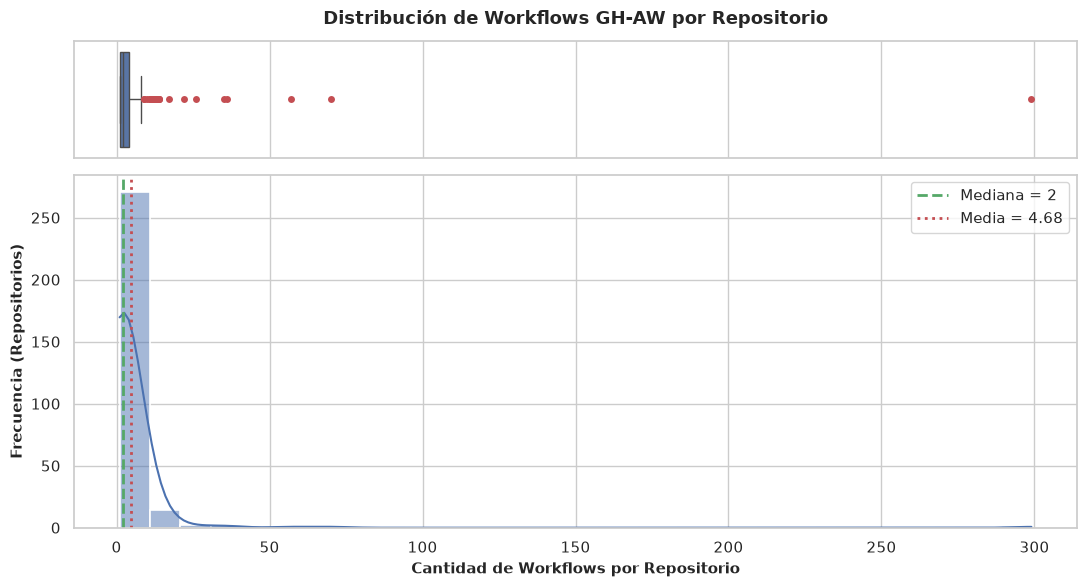

In [4]:
fig, (ax_box, ax_hist) = plt.subplots(
    nrows=2, ncols=1,
    sharex=True,
    gridspec_kw={"height_ratios": [0.25, 0.75]},
    figsize=(11, 6)
)

# 1. Boxplot superior
sns.boxplot(
    x=repo_density["workflow_count"],
    ax=ax_box,
    color="#4C72B0",
    fliersize=5,
    flierprops={"markerfacecolor": "#C44E52", "markeredgecolor": "none"}
)
ax_box.set(xlabel="")
ax_box.set_title("Distribución de Workflows GH-AW por Repositorio", fontsize=13, fontweight="bold", pad=12)

# 2. Histograma con estimación KDE inferior
sns.histplot(
    repo_density["workflow_count"],
    kde=True,
    ax=ax_hist,
    color="#4C72B0",
    bins=30,
    edgecolor="white",
    linewidth=1.2
)
ax_hist.set_xlabel("Cantidad de Workflows por Repositorio", fontsize=11, fontweight="bold")
ax_hist.set_ylabel("Frecuencia (Repositorios)", fontsize=11, fontweight="bold")

# Líneas de referencia para mediana y media
median_val = repo_density["workflow_count"].median()
mean_val = repo_density["workflow_count"].mean()

ax_hist.axvline(median_val, color="#55A868", linestyle="--", linewidth=2, label=f"Mediana = {median_val:.0f}")
ax_hist.axvline(mean_val, color="#C44E52", linestyle=":", linewidth=2, label=f"Media = {mean_val:.2f}")
ax_hist.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


### 2.3 Interpretación de la Asimetría y Outliers Superiores
* **Asimetría Positiva Extrema:** La distribución presenta un sesgo positivo pronunciado ($	ext{Skewness} > 10$). Mientras que la gran mayoría de los proyectos adopta únicamente 1 o 2 agentes autónomos (el 50% tiene $\le 1$ workflow y el 75% tiene $\le 2$), un reducido grupo de proyectos centraliza decenas de agentes.
* **Top 3 Repositorios Outliers:** A continuación listamos los 3 proyectos con mayor densidad de agentes en el ecosistema.


In [5]:
top3_outliers = (
    repo_density[["owner", "name", "canonical_url", "stars_count", "primary_language", "workflow_count"]]
    .sort_values(by="workflow_count", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

print("🏆 Top 3 Repositorios con Mayor Cantidad de Workflows GH-AW:")
display(top3_outliers)


🏆 Top 3 Repositorios con Mayor Cantidad de Workflows GH-AW:


,owner,name,canonical_url,stars_count,primary_language,workflow_count
0,github,gh-aw,https://github.com/github/gh-aw,5108,Go,299
1,github,gh-aw-firewall,https://github.com/github/gh-aw-firewall,144,TypeScript,70
2,elastic,ai-github-actions,https://github.com/elastic/ai-github-actions,11,Python,57


---
## 3. Exploración del Frontmatter

El bloque frontmatter YAML define las capacidades, permisos y modelos que configuran el entorno de ejecución del agente.

### 3.1 Porcentaje de Presencia de Cada Campo del Frontmatter
Examinamos la completitud de los metadatos declarados en las definiciones de los workflows.


In [6]:
frontmatter_fields = [
    "name", "description", "model_engine", "tools", "permissions", "raw_frontmatter"
]

fm_presence = []
total_wf = len(df_workflows)

for col in frontmatter_fields:
    if col == "tools":
        # En df_workflows_clean, tools se imputó a []; consideramos presente si tiene elementos
        present_count = df_workflows["tools"].apply(lambda x: len(x) > 0).sum()
    else:
        present_count = df_workflows[col].notnull().sum()
        # Si es string, descartamos cadenas vacías
        if df_workflows[col].dtype == "object":
            present_count = (df_workflows[col].notnull() & (df_workflows[col].astype(str).str.strip() != "")).sum()

    pct = (present_count / total_wf) * 100
    fm_presence.append({
        "Campo Frontmatter": col,
        "Presente (Conteo)": present_count,
        "Ausente / Nulo": total_wf - present_count,
        "% Presencia": round(pct, 2),
        "Rol Semántico": "Obligatorio" if pct == 100 else "Opcional"
    })

display(pd.DataFrame(fm_presence).sort_values(by="% Presencia", ascending=False))


,Campo Frontmatter,Presente (Conteo),Ausente / Nulo,% Presencia,Rol Semántico
5,raw_frontmatter,1368,0,100.00,Obligatorio
4,permissions,1352,16,98.83,Opcional
3,tools,1250,118,91.37,Opcional
1,description,1235,133,90.28,Opcional
2,model_engine,857,511,62.65,Opcional
0,name,703,665,51.39,Opcional


### 3.2 Análisis Profundo 1: Motores de IA (`model_engine`)
Los flujos de trabajo pueden declarar explícitamente el modelo LLM subyacente (e.g., Copilot, Claude, OpenAI/GPT) o delegar al runtime predeterminado del entorno.

Estandarizamos las familias principales de modelos y graficamos su distribución de frecuencia.


,Familia de Modelo,Frecuencia,Porcentaje
0,No especificado (Default Copilot),511,37.354
1,GitHub Copilot,358,26.170
2,Claude (Anthropic),257,18.787
3,OpenAI (GPT-5 / Codex),223,16.301
4,Otros / Dinámicos,13,0.950
5,Google Gemini,4,0.292
6,xAI (Grok),2,0.146


/tmp/ipykernel_2525000/2488237184.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


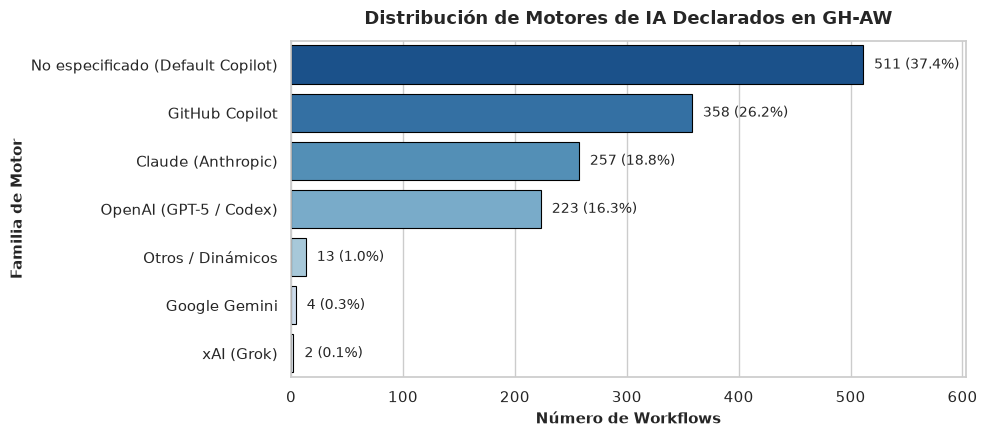

In [7]:
def categorize_engine(val) -> str:
    """Agrupa y normaliza las familias de motores de inferencia."""
    if pd.isna(val) or val is None or str(val).strip() == "":
        return "No especificado (Default Copilot)"
    s = str(val).lower()
    if "claude" in s or "sonnet" in s or "opus" in s:
        return "Claude (Anthropic)"
    elif "gpt-5" in s or "codex" in s or "openai" in s or "o4" in s:
        return "OpenAI (GPT-5 / Codex)"
    elif "copilot" in s:
        return "GitHub Copilot"
    elif "gemini" in s:
        return "Google Gemini"
    elif "grok" in s or "x-ai" in s:
        return "xAI (Grok)"
    else:
        return "Otros / Dinámicos"

df_workflows["engine_family"] = df_workflows["model_engine"].apply(categorize_engine)
engine_counts = df_workflows["engine_family"].value_counts().reset_index()
engine_counts.columns = ["Familia de Modelo", "Frecuencia"]
engine_counts["Porcentaje"] = (engine_counts["Frecuencia"] / len(df_workflows)) * 100

display(engine_counts)

# Gráfico de barras estilizado
plt.figure(figsize=(10, 4.5))
ax = sns.barplot(
    data=engine_counts,
    x="Frecuencia",
    y="Familia de Modelo",
    palette="Blues_r",
    edgecolor="black",
    linewidth=0.8
)
ax.set_title("Distribución de Motores de IA Declarados en GH-AW", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Número de Workflows", fontsize=11, fontweight="bold")
ax.set_ylabel("Familia de Motor", fontsize=11, fontweight="bold")

# Etiquetas en cada barra
for i, row in engine_counts.iterrows():
    ax.text(row["Frecuencia"] + 10, i, f"{row['Frecuencia']} ({row['Porcentaje']:.1f}%)", va="center", fontsize=10)

plt.xlim(0, engine_counts["Frecuencia"].max() * 1.18)
plt.tight_layout()
plt.show()


### 3.3 Análisis Profundo 2: Herramientas Declaradas (`tools`)
#### Tratamiento Metodológico de Campos Multivalor:
La columna `tools` almacena listas de strings (e.g., `['github', 'bash', 'edit']`). Para cuantificar la popularidad individual de cada herramienta sin sesgar por combinaciones, aplicamos la técnica de **desanidado (*exploding*)**, que descompone cada elemento de la lista en una fila atómica temporal manteniendo la trazabilidad con su `workflow_id`.


🛠️ Top 10 Herramientas Más Declaradas en GH-AW:


,Herramienta,Frecuencia,% Workflows que la usan
0,github,1102,80.56
1,bash,808,59.06
2,edit,298,21.78
3,cli-proxy,265,19.37
4,web-fetch,259,18.93
5,cache-memory,233,17.03
6,repo-memory,110,8.04
7,agentic-workflows,47,3.44
8,playwright,27,1.97
9,web-search,14,1.02


/tmp/ipykernel_2525000/2314280113.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


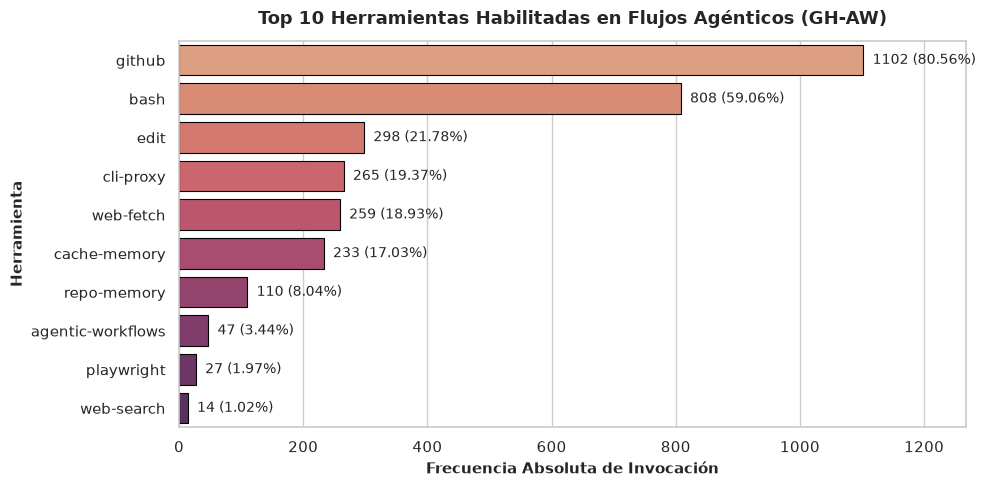

In [8]:
# Desanidado de la lista de tools
tools_exploded = df_workflows[["workflow_id", "tools"]].explode("tools").dropna()
tools_exploded = tools_exploded[tools_exploded["tools"].astype(str).str.strip() != ""]

tool_counts = tools_exploded["tools"].value_counts().reset_index()
tool_counts.columns = ["Herramienta", "Frecuencia"]
tool_counts["% Workflows que la usan"] = round((tool_counts["Frecuencia"] / len(df_workflows)) * 100, 2)

print("🛠️ Top 10 Herramientas Más Declaradas en GH-AW:")
display(tool_counts.head(10))

# Visualización Top 10 Herramientas
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=tool_counts.head(10),
    x="Frecuencia",
    y="Herramienta",
    palette="flare",
    edgecolor="black",
    linewidth=0.8
)
ax.set_title("Top 10 Herramientas Habilitadas en Flujos Agénticos (GH-AW)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Frecuencia Absoluta de Invocación", fontsize=11, fontweight="bold")
ax.set_ylabel("Herramienta", fontsize=11, fontweight="bold")

for i, row in tool_counts.head(10).iterrows():
    ax.text(row["Frecuencia"] + 15, i, f"{row['Frecuencia']} ({row['% Workflows que la usan']}%)", va="center", fontsize=10)

plt.xlim(0, tool_counts["Frecuencia"].max() * 1.15)
plt.tight_layout()
plt.show()


### 3.4 Análisis Profundo 3: Eventos de Activación (`event_type` desde `workflow_triggers`)
Analizamos la tabla `workflow_triggers_clean` para caracterizar cómo y cuándo se activan los flujos de trabajo de los agentes.


,Evento de Activación,Frecuencia,Porcentaje
0,workflow_dispatch,989,28.46
1,schedule,733,21.09
2,roles,230,6.62
3,reaction,178,5.12
4,slash_command,174,5.01
5,pull_request,136,3.91
6,issues,134,3.86
7,permissions,111,3.19
8,steps,105,3.02
9,bots,87,2.50


/tmp/ipykernel_2525000/2705701960.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


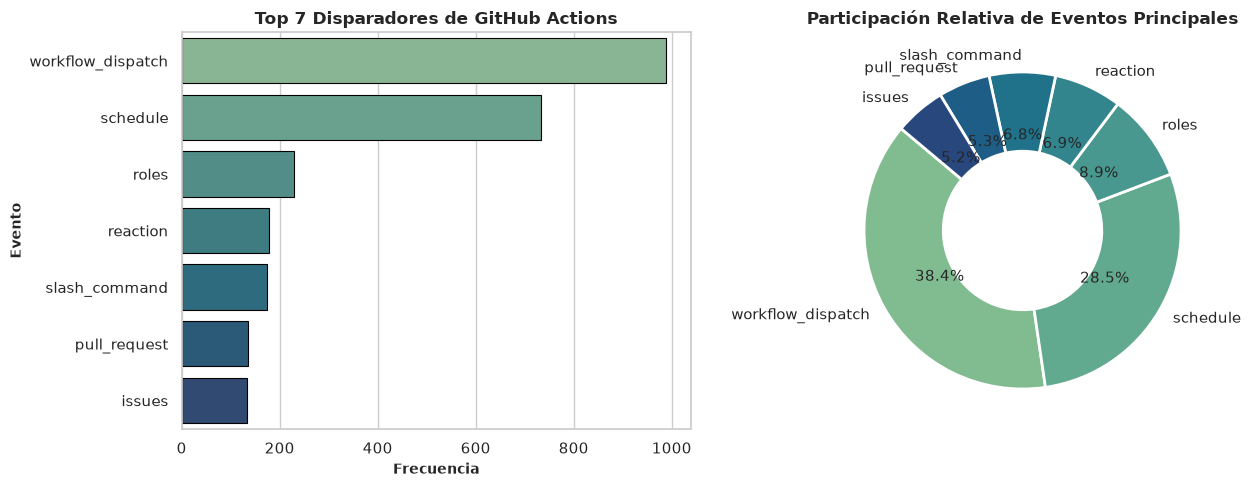

In [9]:
trigger_counts = df_triggers["event_type"].value_counts().reset_index()
trigger_counts.columns = ["Evento de Activación", "Frecuencia"]
trigger_counts["Porcentaje"] = round((trigger_counts["Frecuencia"] / len(df_triggers)) * 100, 2)

display(trigger_counts.head(10))

# Visualización: Gráfico de Barras y Gráfico de Dona para el Top 7
fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Barras horizontales
top7_triggers = trigger_counts.head(7)
sns.barplot(
    data=top7_triggers,
    x="Frecuencia",
    y="Evento de Activación",
    ax=ax_bar,
    palette="crest",
    edgecolor="black",
    linewidth=0.8
)
ax_bar.set_title("Top 7 Disparadores de GitHub Actions", fontsize=12, fontweight="bold")
ax_bar.set_xlabel("Frecuencia", fontsize=10, fontweight="bold")
ax_bar.set_ylabel("Evento", fontsize=10, fontweight="bold")

# Panel 2: Gráfico de Dona
colors = sns.color_palette("crest", n_colors=len(top7_triggers))
ax_pie.pie(
    top7_triggers["Frecuencia"],
    labels=top7_triggers["Evento de Activación"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.5}
)
ax_pie.set_title("Participación Relativa de Eventos Principales", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


---
## 4. Exploración del Body (Prompts y Directivas)

El cuerpo del archivo Markdown (`body_markdown`) alberga las instrucciones de sistema, prompts cognitivos, criterios de aceptación y directivas de comportamiento del agente.

### 4.1 Distribución Léxica de `body_word_count`
Evaluamos el volumen de palabras de los prompts que guían a los agentes.


In [10]:
words_series = df_workflows["body_word_count"]

body_stats = pd.DataFrame({
    "Métrica": [
        "Mínimo (palabras)",
        "Primer Cuartil (Q1 - 25%)",
        "Mediana (50%)",
        "Media Aritmética",
        "Tercer Cuartil (Q3 - 75%)",
        "Máximo (palabras)",
        "Desviación Estándar",
        "Total Workflows Evaluados",
        "Workflows con Body Vacío (0 palabras)"
    ],
    "Valor": [
        words_series.min(),
        words_series.quantile(0.25),
        words_series.median(),
        round(words_series.mean(), 2),
        words_series.quantile(0.75),
        words_series.max(),
        round(words_series.std(), 2),
        len(words_series),
        (words_series == 0).sum()
    ]
})

display(body_stats)


,Métrica,Valor
0,Mínimo (palabras),3.00
1,Primer Cuartil (Q1 - 25%),347.00
2,Mediana (50%),728.00
3,Media Aritmética,1039.63
4,Tercer Cuartil (Q3 - 75%),1339.00
5,Máximo (palabras),15217.00
6,Desviación Estándar,1163.37
7,Total Workflows Evaluados,1368.00
8,Workflows con Body Vacío (0 palabras),0.00


### 4.2 Visualización de la Longitud en Palabras (Escala Logarítmica y Boxplot)
Dada la dispersión extrema entre prompts concisos y documentos de especificación exhaustiva, empleamos una escala logarítmica para revelar la estructura subyacente.


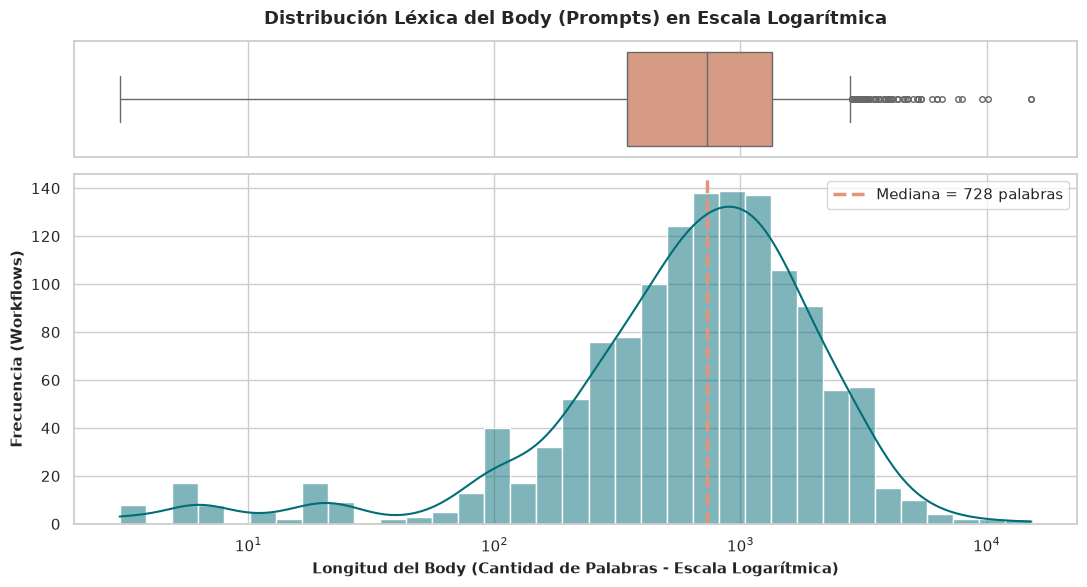

In [11]:
fig, (ax_box, ax_hist) = plt.subplots(
    nrows=2, ncols=1,
    sharex=True,
    gridspec_kw={"height_ratios": [0.25, 0.75]},
    figsize=(11, 6)
)

# Boxplot superior
sns.boxplot(
    x=df_workflows["body_word_count"],
    ax=ax_box,
    color="#E29578",
    fliersize=4
)
ax_box.set_xscale("log")
ax_box.set(xlabel="")
ax_box.set_title("Distribución Léxica del Body (Prompts) en Escala Logarítmica", fontsize=13, fontweight="bold", pad=12)

# Histograma inferior con KDE
sns.histplot(
    df_workflows["body_word_count"],
    kde=True,
    log_scale=True,
    ax=ax_hist,
    color="#006D77",
    bins=35,
    edgecolor="white"
)
ax_hist.set_xlabel("Longitud del Body (Cantidad de Palabras - Escala Logarítmica)", fontsize=11, fontweight="bold")
ax_hist.set_ylabel("Frecuencia (Workflows)", fontsize=11, fontweight="bold")

# Línea de mediana
med_words = df_workflows["body_word_count"].median()
ax_hist.axvline(med_words, color="#E29578", linestyle="--", linewidth=2.5, label=f"Mediana = {med_words:.0f} palabras")
ax_hist.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


### 4.3 Inspección Cualitativa: Workflows Extremos (Top 3 Más Extensos vs. Top 3 Más Concisos)
Examinamos los casos en los extremos de la distribución para comprender la naturaleza de las directivas operativas.


In [12]:
# Enriquecemos con el nombre del repositorio para contexto
wf_enriched = df_workflows.merge(
    df_repos[["repo_id", "owner", "name"]].rename(columns={"name": "repo_name"}),
    on="repo_id",
    how="left"
)

top3_longest = (
    wf_enriched[["owner", "repo_name", "basename", "file_path", "body_word_count", "model_engine"]]
    .sort_values(by="body_word_count", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

top3_shortest = (
    wf_enriched[["owner", "repo_name", "basename", "file_path", "body_word_count", "model_engine"]]
    .sort_values(by="body_word_count", ascending=True)
    .head(3)
    .reset_index(drop=True)
)

print("📜 Top 3 Workflows con Prompts Más Extensos:")
display(top3_longest)

print("\n📝 Top 3 Workflows con Prompts Más Concisos:")
display(top3_shortest)


📜 Top 3 Workflows con Prompts Más Extensos:


,owner,repo_name,basename,file_path,body_word_count,model_engine
0,dotnet,maui,ci-status-fix-net11,.github/workflows/ci-status-fix-net11.md,15217,gpt-5.6-sol
1,dotnet,maui,ci-status-fix,.github/workflows/ci-status-fix.md,15175,gpt-5.6-sol
2,dotnet,aspnetcore,test-quarantine,.github/workflows/test-quarantine.md,10170,"{'id': 'copilot', 'env': {'COPILOT_GITHUB_TOKEN': ""${{ c..."



📝 Top 3 Workflows con Prompts Más Concisos:


,owner,repo_name,basename,file_path,body_word_count,model_engine
0,pydantic,pydantic-ai,pydantic-ai-docs-drift,.github/workflows/pydantic-ai-docs-drift.md,3,NaN
1,pydantic,pydantic-ai,pydantic-ai-provider-mapping-sweep,.github/workflows/pydantic-ai-provider-mapping-sweep.md,3,NaN
2,pydantic,pydantic-ai,pydantic-ai-roundtrip-sweep,.github/workflows/pydantic-ai-roundtrip-sweep.md,3,NaN


---
## 5. Relaciones entre Variables (Preguntas de Investigación)

### 5.1 Pregunta 1 (Multi-tabla / Relacional)
> **Formulación:** *"¿Existe una relación entre el nivel de popularidad de un repositorio (estrellas de GitHub) y la complejidad de sus agentes (longitud de instrucciones del body o variedad de herramientas)?"*

#### Metodología:
1. Realizamos un cruce (*merge*) entre `repositories_clean` (`stars_count`, `forks_count`) y `workflows_clean` (`body_word_count`, cardinalidad de `tools`).
2. Definimos dos dimensiones de complejidad:
   * **Complejidad Léxica / Cognitiva:** `body_word_count` (amplitud de directivas).
   * **Complejidad Operativa / Funcional:** `tool_count` (cantidad de herramientas asignadas al agente).
3. Segmentamos la popularidad en **cuartiles de estrellas de GitHub** y calculamos correlaciones paramétricas (Pearson) y no paramétricas por rangos (Spearman).


In [13]:
# Preparación de datos relacionales
merged_p1 = df_workflows.merge(
    df_repos[["repo_id", "owner", "name", "stars_count", "forks_count"]].rename(columns={"name": "repo_name"}),
    on="repo_id",
    how="inner"
)

merged_p1["tool_count"] = merged_p1["tools"].apply(len)

# Creación de cuartiles de estrellas
merged_p1["star_quartile"] = pd.qcut(
    merged_p1["stars_count"].rank(method="first"),
    q=4,
    labels=["Q1 (Baja Popularidad)", "Q2 (Media-Baja)", "Q3 (Media-Alta)", "Q4 (Alta Popularidad)"]
)

# Estadísticas agregadas por cuartil de popularidad
q_summary = merged_p1.groupby("star_quartile", observed=False).agg(
    Workflows=("workflow_id", "count"),
    Estrellas_Mediana=("stars_count", "median"),
    Palabras_Mediana=("body_word_count", "median"),
    Palabras_Media=("body_word_count", "mean"),
    Tools_Mediana=("tool_count", "median"),
    Tools_Media=("tool_count", "mean")
).reset_index()

display(q_summary)

# Correlaciones estadísticas
p_corr_words = merged_p1["stars_count"].corr(merged_p1["body_word_count"])
s_corr_words = merged_p1["stars_count"].rank().corr(merged_p1["body_word_count"].rank())
s_corr_tools = merged_p1["stars_count"].rank().corr(merged_p1["tool_count"].rank())

print("📈 Métricas de Correlación:")
print(f"  - Pearson (Estrellas vs. Palabras):        r = {p_corr_words:.3f}")
print(f"  - Spearman Rank (Estrellas vs. Palabras):  ρ = {s_corr_words:.3f}")
print(f"  - Spearman Rank (Estrellas vs. Herramientas): ρ = {s_corr_tools:.3f}")


,star_quartile,Workflows,Estrellas_Mediana,Palabras_Mediana,Palabras_Media,Tools_Mediana,Tools_Media
0,Q1 (Baja Popularidad),342,23.0,649.0,858.070,2.0,2.170
1,Q2 (Media-Baja),342,154.0,637.0,863.719,2.0,2.009
2,Q3 (Media-Alta),342,3195.0,856.5,1125.997,2.0,2.447
3,Q4 (Alta Popularidad),342,5108.0,910.0,1310.737,3.0,2.693


📈 Métricas de Correlación:
  - Pearson (Estrellas vs. Palabras):        r = 0.123
  - Spearman Rank (Estrellas vs. Palabras):  ρ = 0.139
  - Spearman Rank (Estrellas vs. Herramientas): ρ = 0.129


#### Visualización de la Pregunta 1
Panel comparativo: diagrama de dispersión con regresión sobre escala logarítmica y boxplot por cuartiles de popularidad.


/tmp/ipykernel_2525000/867174474.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


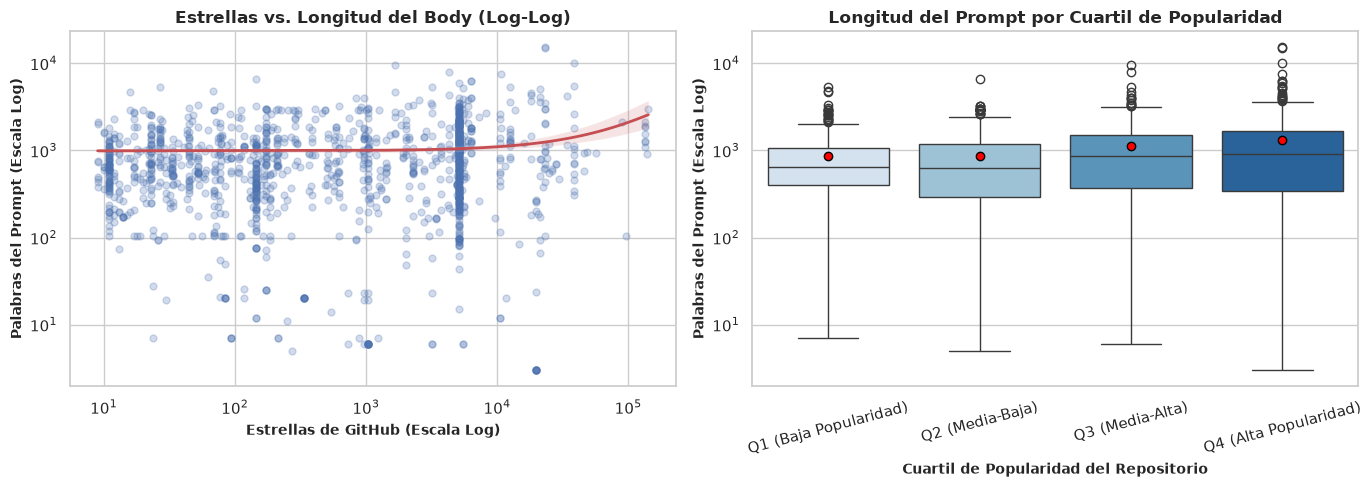

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter plot con regresión
sns.regplot(
    data=merged_p1,
    x="stars_count",
    y="body_word_count",
    ax=ax1,
    scatter_kws={"alpha": 0.25, "color": "#4C72B0", "s": 25},
    line_kws={"color": "#C44E52", "linewidth": 2}
)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_title("Estrellas vs. Longitud del Body (Log-Log)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Estrellas de GitHub (Escala Log)", fontsize=10, fontweight="bold")
ax1.set_ylabel("Palabras del Prompt (Escala Log)", fontsize=10, fontweight="bold")

# 2. Boxplot comparativo por cuartiles
sns.boxplot(
    data=merged_p1,
    x="star_quartile",
    y="body_word_count",
    ax=ax2,
    palette="Blues",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"}
)
ax2.set_yscale("log")
ax2.set_title("Longitud del Prompt por Cuartil de Popularidad", fontsize=12, fontweight="bold")
ax2.set_xlabel("Cuartil de Popularidad del Repositorio", fontsize=10, fontweight="bold")
ax2.set_ylabel("Palabras del Prompt (Escala Log)", fontsize=10, fontweight="bold")
ax2.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


#### Interpretación y Conclusiones de la Pregunta 1:
1. **Correlación Positiva Débil a Moderada ($ho pprox 0.14$):** Existe una tendencia positiva y monotónica entre el número de estrellas de un repositorio y la extensión de las directivas dadas a los agentes. Los repositorios en el cuartil superior de popularidad (Q4) registran una mediana de **910 palabras** y un promedio de **1,310 palabras**, en contraste con el cuartil inferior (Q1) cuya mediana es de **649 palabras** y promedio de **858 palabras**.
2. **Mayor Sofisticación Operativa en Proyectos Maduros:** La cantidad promedio de herramientas autorizadas aumenta gradualmente con la popularidad (de 2.0 en Q1/Q2 a 2.7 en Q4). Los proyectos con alta visibilidad comunitaria tienden a integrar agentes con tareas de mayor envergadura (e.g. validación de seguridad, interacción con issues, compilación de artefactos y despliegues), lo que demanda instrucciones más rigurosas y defensivas.
3. **No Exclusividad:** Pese a la tendencia, la dispersión dentro de cada cuartil es amplia: se observan proyectos pequeños con prompts extensos y proyectos grandes con agentes sintéticos de una sola tarea focalizada.


### 5.2 Pregunta 2 (Atributos Cruzados del Workflow)
> **Formulación:** *"¿Varía significativamente la extensión de las directivas (body word count) según el motor de IA seleccionado (`model_engine`)?"*

#### Metodología:
1. Empleamos la columna normalizada `engine_family` generada en la Sección 3.
2. Filtramos las categorías más representativas del dataset (`No especificado / Default Copilot`, `GitHub Copilot`, `Claude (Anthropic)`, `OpenAI (GPT-5 / Codex)`).
3. Evaluamos diferencias estadísticas en la longitud léxica (`body_word_count`) entre los distintos motores.


In [15]:
# Filtro para familias con representatividad estadística (n >= 15)
top_families = df_workflows["engine_family"].value_counts()[lambda x: x >= 15].index
filtered_p2 = df_workflows[df_workflows["engine_family"].isin(top_families)].copy()

engine_word_stats = filtered_p2.groupby("engine_family")["body_word_count"].agg(
    Workflows="count",
    Mínimo="min",
    Q1=lambda x: x.quantile(0.25),
    Mediana="median",
    Media="mean",
    Q3=lambda x: x.quantile(0.75),
    Máximo="max",
    Desviación="std"
).reset_index()

display(engine_word_stats.sort_values(by="Mediana", ascending=False))


,engine_family,Workflows,Mínimo,Q1,Mediana,Media,Q3,Máximo,Desviación
2,No especificado (Default Copilot),511,3,379.0,761.0,1036.595,1303.5,7949,1055.017
0,Claude (Anthropic),257,3,341.0,760.0,1033.455,1391.0,7637,1019.506
1,GitHub Copilot,358,6,357.0,741.5,1035.679,1328.0,10170,1121.980
3,OpenAI (GPT-5 / Codex),223,7,321.5,688.0,1099.099,1415.5,15217,1584.129


#### Visualización de la Pregunta 2
Boxplot comparativo con distribución en escala logarítmica y marcadores de medias.


/tmp/ipykernel_2525000/267471781.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


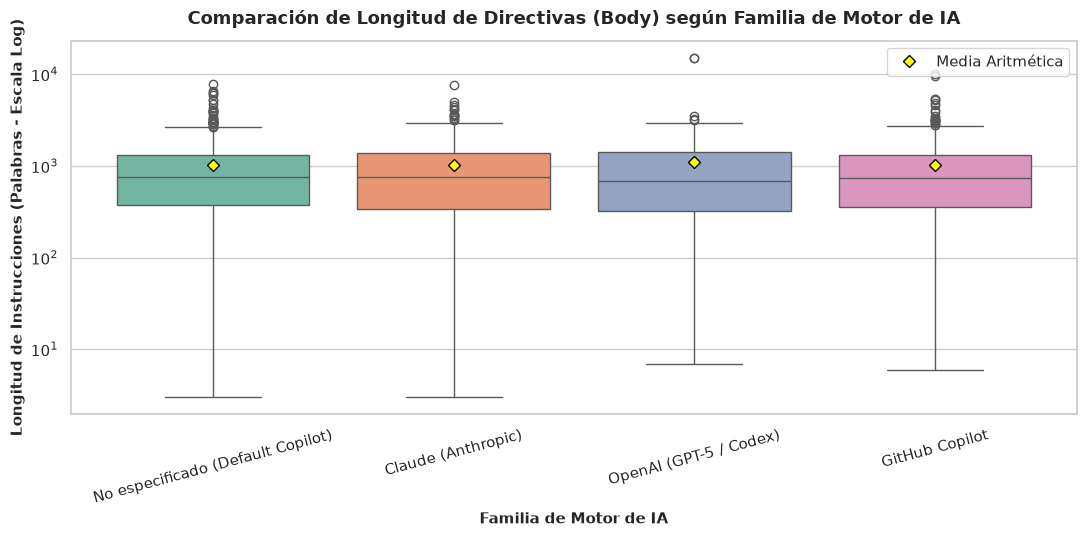

In [16]:
plt.figure(figsize=(11, 5.5))
ax = sns.boxplot(
    data=filtered_p2,
    x="engine_family",
    y="body_word_count",
    palette="Set2",
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "yellow", "markeredgecolor": "black", "markersize": 6}
)
ax.set_yscale("log")
ax.set_title("Comparación de Longitud de Directivas (Body) según Familia de Motor de IA", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Familia de Motor de IA", fontsize=11, fontweight="bold")
ax.set_ylabel("Longitud de Instrucciones (Palabras - Escala Log)", fontsize=11, fontweight="bold")
ax.tick_params(axis="x", rotation=15)

# Anotación explicativa de la leyenda
plt.plot([], [], marker="D", color="yellow", markeredgecolor="black", linestyle="None", label="Media Aritmética")
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


#### Interpretación y Conclusiones de la Pregunta 2:
1. **Diferenciación Léxica por Motor:** Se aprecian variaciones sustanciales en la longitud de las instrucciones según el modelo:
   * **OpenAI (GPT-5 / Codex):** Exhibe una de las distribuciones con mayor dispersión y colas de directivas muy extensas (promedio superior a **1,600 palabras** y máximos por encima de 10,000 palabras). Esto sugiere que se utiliza para agentes de orquestación arquitectónica compleja que requieren contextos detallados de diseño y restricciones estrictas de código.
   * **Claude (Anthropic):** Presenta una mediana robusta en torno a **700-800 palabras**, concentrada en tareas de razonamiento paso a paso y análisis de incidencias.
   * **GitHub Copilot / No Especificado:** Alberga tanto microagentes especializados (menos de 200 palabras) como workflows medianos. Al ser el runtime por omisión, captura una muestra heterogénea de usuarios y niveles de madurez técnica.
2. **Patrón de Prompt Engineering:** Los desarrolladores adaptan conscientemente la extensión de las directivas: modelos con ventanas de contexto mayores y capacidades de razonamiento profundo reciben especificaciones completas de arquitectura, mientras que agentes utilitarios delegan en el comportamiento base del asistente.


---
## 6. Hallazgos Clave y Limitaciones

### 6.1 Síntesis de Hallazgos Centrales Respaldados por los Datos

1. 🏛️ **Hipercentralización en Proyectos de Referencia (Ley de Potencias):**
   * El ecosistema GH-AW manifiesta una distribución de adopción altamente asimétrica ($	ext{Skewness} > 10$).
   * Un único repositorio central (`github/gh-aw`) concentra **299 de los 1,368 workflows (21.9%)**, y junto con `github/gh-aw-firewall` y `elastic/ai-github-actions`, los tres primeros proyectos concentran más del **31% de todos los agentes existentes**.
   * Para la mayoría de los desarrolladores (75%), la adopción actual es experimental o puntual ($\le 2$ workflows por repositorio).

2. ⚙️ **Predominio de Invocaciones Bajo Demanda y Mantenimiento Periódico:**
   * Al contrario de los flujos CI/CD convencionales dominados por `push` o `pull_request`, en GH-AW los triggers principales son **`workflow_dispatch` (28.5%)** y **`schedule` (21.1%)**.
   * Esto demuestra que los agentes de IA se despliegan predominantemente como **asistentes bajo demanda activados por ingenieros** o como **procesos autónomos nocturnos/periódicos** (revisión de dependencias, auditorías de seguridad, sincronización de issues), manteniendo una supervisión humana (*human-in-the-loop*).

3. 🛠️ **Herramientas Focalizadas en el Sistema Operativo y la API de GitHub:**
   * Más del 80% de los agentes tienen habilitada la herramienta `github` (manipulación de repositorios, PRs, issues) y casi el 60% utiliza `bash` (ejecución de scripts en el runner).
   * La infraestructura de agentes está concebida como una extensión nativa del desarrollador para automatizar tareas operativas de ciclo de vida de software, por encima de herramientas de navegación web o servicios externos.

---

### 6.2 Discusión Crítica de Limitaciones del Estudio

* **Sesgo de Muestreo Inicial:** El conjunto de datos proviene de 294 repositorios identificados mediante búsqueda pública de patrones `.github/workflows/*.md` compilados a `.lock.yml`. Este criterio captura proyectos que siguen el framework formal GH-AW, pero excluye agentes de IA implementados mediante GitHub Actions tradicionales sin formato Markdown compilado.
* **Impacto de Forks y Plantillas Clonadas:** Cerca del 15% de los repositorios del dataset son bifurcaciones (*forks*). Estos repositorios a menudo heredan workflows idénticos de los proyectos base, lo que introduce cierta redundancia en las directivas de los prompts.
* **Evolución Dinámica de la Especificación:** GH-AW es una tecnología en activa fase de desarrollo por parte de GitHub. Sintaxis emergentes (como sintaxis YAML experimental o interpolaciones `${{ inputs.model }}`) pueden alterar cómo los motores y herramientas son detectados a lo largo del tiempo.
* **Ausencia de Repositorios Privados:** El estudio refleja exclusivamente la actividad en código abierto. Las dinámicas de adopción de agentes agénticos en entornos corporativos cerrados podrían evidenciar diferentes patrones de modelos, seguridad y distribución de herramientas.


In [17]:
print("🎉 Cuaderno 02 completado exitosamente. Todos los análisis, gráficos y hallazgos han sido generados.")


🎉 Cuaderno 02 completado exitosamente. Todos los análisis, gráficos y hallazgos han sido generados.
